In [1]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Day 7: Risk Engine Verification Notebook                            ║
# ║  Goal: Fit risk engine on training anomaly scores, evaluate on test  ║
# ║  Output: Calibrated 0-100 risk scores with risk bands              ║
# ╚══════════════════════════════════════════════════════════════════════╝

import sys
from pathlib import Path

# Ensure project root is on path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.preprocessing import MinMaxScaler

from src.config import settings
from src.risk_engine import RiskEngine, compute_anomaly_scores, compute_risk_scores

print("✅ Imports OK")
print(f"   Python: {sys.version.split()[0]}")
print(f"   NumPy:  {np.__version__}")
print(f"   Pandas: {pd.__version__}")
print(f"   Project root: {PROJECT_ROOT}")

✅ Imports OK
   Python: 3.10.20
   NumPy:  2.2.6
   Pandas: 2.3.3
   Project root: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI


In [4]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 2: Load trained model and recreate stratified train/test split ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── Debug paths ─────────────────────────────────────────────────────────
print("Debug paths:")
print(f"   PROJECT_ROOT:     {PROJECT_ROOT}")
print(f"   settings.MODEL_PATH: {settings.MODEL_PATH}")
print(f"   settings.PROCESSED_DATA_PATH: {settings.PROCESSED_DATA_PATH}")

# Build absolute paths manually
model_path = Path(PROJECT_ROOT) / "saved_models" / "isolation_forest_v1.0.0.joblib"
features_path = Path(PROJECT_ROOT) / "data" / "processed" / "features.csv"

print(f"\n   Resolved model path:     {model_path}")
print(f"   Resolved features path:  {features_path}")
print(f"   Model exists:            {model_path.exists()}")
print(f"   Features exists:         {features_path.exists()}")

# ── Load trained model (dict container) ──────────────────────────────
model_container = joblib.load(model_path)
model = model_container["model"]
feature_names = model_container["feature_names"]

print(f"\n✅ Model loaded: {model_container['version']}")
print(f"   Estimators:   {model_container['n_estimators']}")
print(f"   Features:     {len(feature_names)}")
print(f"   Contamination:{model_container['contamination']}")

# ── Load features and recreate split ─────────────────────────────────
df = pd.read_csv(features_path)

# Stratified split (same as Day 4/5)
from sklearn.model_selection import train_test_split

X = df[feature_names]
y = df["isFraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f"\n✅ Data split:")
print(f"   Train: {len(X_train):,} rows ({y_train.sum():,} frauds, {y_train.mean()*100:.3f}%)")
print(f"   Test:  {len(X_test):,} rows ({y_test.sum():,} frauds, {y_test.mean()*100:.3f}%)")

Debug paths:
   PROJECT_ROOT:     F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI
   settings.MODEL_PATH: ./saved_models
   settings.PROCESSED_DATA_PATH: data/processed/features.csv

   Resolved model path:     F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\saved_models\isolation_forest_v1.0.0.joblib
   Resolved features path:  F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\data\processed\features.csv
   Model exists:            True
   Features exists:         True

✅ Model loaded: 1.0.0
   Estimators:   200
   Features:     24
   Contamination:0.01

✅ Data split:
   Train: 5,090,096 rows (6,570 frauds, 0.129%)
   Test:  1,272,524 rows (1,643 frauds, 0.129%)


In [5]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 3: Compute anomaly scores on TRAIN set, fit Risk Engine        ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── Compute anomaly scores on training data ────────────────────────────
print("Computing anomaly scores on training set (this may take 30-60s)...")
train_scores = compute_anomaly_scores(model, X_train)

print(f"✅ Training scores computed")
print(f"   Count:    {len(train_scores):,}")
print(f"   Min:      {train_scores.min():.6f}")
print(f"   Max:      {train_scores.max():.6f}")
print(f"   Mean:     {train_scores.mean():.6f}")
print(f"   Median:   {np.median(train_scores):.6f}")
print(f"   Std:      {train_scores.std():.6f}")

# ── Fit Risk Engine on training scores ─────────────────────────────────
print("\nFitting Risk Engine (percentile-based calibration)...")
risk_engine = RiskEngine(percentile_bins=100)
risk_engine.fit(train_scores)

print(f"✅ Risk Engine fitted: {risk_engine}")
print(f"   Percentile boundaries: {len(risk_engine._percentiles)} values")
print(f"   0th percentile (min):  {risk_engine._percentiles[0]:.6f}")
print(f"   50th percentile:       {risk_engine._percentiles[50]:.6f}")
print(f"   100th percentile (max):{risk_engine._percentiles[100]:.6f}")

# ── Quick sanity: transform a few training scores ─────────────────────
sample_scores = np.percentile(train_scores, [0, 10, 25, 50, 75, 90, 99, 100])
sample_risks = risk_engine.transform(sample_scores)

print(f"\nSample calibration:")
print(f"   Score → Risk: {list(zip(sample_scores.round(4), sample_risks))}")

Computing anomaly scores on training set (this may take 30-60s)...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   23.2s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  1.6min
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:  1.6min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   21.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:  1.4min
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:  1.4min finished


✅ Training scores computed
   Count:    5,090,096
   Min:      0.000000
   Max:      1.000000
   Mean:     0.187203
   Median:   0.158393
   Std:      0.127434

Fitting Risk Engine (percentile-based calibration)...
✅ Risk Engine fitted: RiskEngine(bins=100, status=fitted)
   Percentile boundaries: 101 values
   0th percentile (min):  0.000000
   50th percentile:       0.158393
   100th percentile (max):1.000000

Sample calibration:
   Score → Risk: [(np.float64(0.0), np.int64(0)), (np.float64(0.0546), np.int64(10)), (np.float64(0.0925), np.int64(25)), (np.float64(0.1584), np.int64(50)), (np.float64(0.2513), np.int64(75)), (np.float64(0.3605), np.int64(90)), (np.float64(0.5944), np.int64(99)), (np.float64(1.0), np.int64(100))]


In [6]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 4: Compute test anomaly scores + risk scores, analyze by label  ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── Compute test anomaly scores ────────────────────────────────────────
print("Computing anomaly scores on test set...")
test_scores = compute_anomaly_scores(model, X_test)

# ── Transform to risk scores ─────────────────────────────────────────
test_risk_scores = risk_engine.transform(test_scores)
test_risk_bands = [risk_engine.get_risk_band(int(s)) for s in test_risk_scores]

print(f"✅ Test scores computed")
print(f"   Count:    {len(test_scores):,}")
print(f"   Min:      {test_scores.min():.6f}")
print(f"   Max:      {test_scores.max():.6f}")
print(f"   Mean:     {test_scores.mean():.6f}")
print(f"   Median:   {np.median(test_scores):.6f}")

# ── Analyze by fraud label ───────────────────────────────────────────
results_df = pd.DataFrame({
    "anomaly_score": test_scores,
    "risk_score": test_risk_scores,
    "risk_band": test_risk_bands,
    "is_fraud": y_test.values,
})

fraud_mask = results_df["is_fraud"] == 1
normal_mask = results_df["is_fraud"] == 0

print(f"\n{'='*55}")
print("RISK SCORE DISTRIBUTION BY LABEL")
print(f"{'='*55}")

print(f"\n📊 NORMAL transactions ({normal_mask.sum():,}):")
print(f"   Risk mean:   {results_df.loc[normal_mask, 'risk_score'].mean():.2f}")
print(f"   Risk median: {results_df.loc[normal_mask, 'risk_score'].median():.1f}")
print(f"   Risk 90th:   {results_df.loc[normal_mask, 'risk_score'].quantile(0.90):.1f}")
print(f"   Risk 99th:   {results_df.loc[normal_mask, 'risk_score'].quantile(0.99):.1f}")

print(f"\n🔴 FRAUD transactions ({fraud_mask.sum():,}):")
print(f"   Risk mean:   {results_df.loc[fraud_mask, 'risk_score'].mean():.2f}")
print(f"   Risk median: {results_df.loc[fraud_mask, 'risk_score'].median():.1f}")
print(f"   Risk 90th:   {results_df.loc[fraud_mask, 'risk_score'].quantile(0.90):.1f}")
print(f"   Risk 99th:   {results_df.loc[fraud_mask, 'risk_score'].quantile(0.99):.1f}")

# ── Risk band breakdown ────────────────────────────────────────────────
print(f"\n{'='*55}")
print("RISK BAND BREAKDOWN")
print(f"{'='*55}")

band_summary = results_df.groupby("risk_band").agg(
    total=("is_fraud", "count"),
    frauds=("is_fraud", "sum"),
    fraud_rate=("is_fraud", "mean"),
).sort_index(key=lambda x: pd.Categorical(x, ["Low", "Medium", "Elevated", "High", "Critical"]))

print(band_summary.to_string())
print(f"\n   Overall fraud rate: {results_df['is_fraud'].mean()*100:.3f}%")

Computing anomaly scores on test set...


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    8.1s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   32.1s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   32.3s finished


✅ Test scores computed
   Count:    1,272,524
   Min:      0.000000
   Max:      1.000000
   Mean:     0.187709
   Median:   0.158846

RISK SCORE DISTRIBUTION BY LABEL

📊 NORMAL transactions (1,270,881):
   Risk mean:   49.57
   Risk median: 50.0
   Risk 90th:   90.0
   Risk 99th:   98.0

🔴 FRAUD transactions (1,643):
   Risk mean:   87.08
   Risk median: 96.0
   Risk 90th:   99.0
   Risk 99th:   99.0

RISK BAND BREAKDOWN
            total  frauds  fraud_rate
risk_band                            
Low        315989      54    0.000171
Medium     318362      65    0.000204
Elevated   318316     129    0.000405
High       191239     279    0.001459
Critical   128618    1116    0.008677

   Overall fraud rate: 0.129%


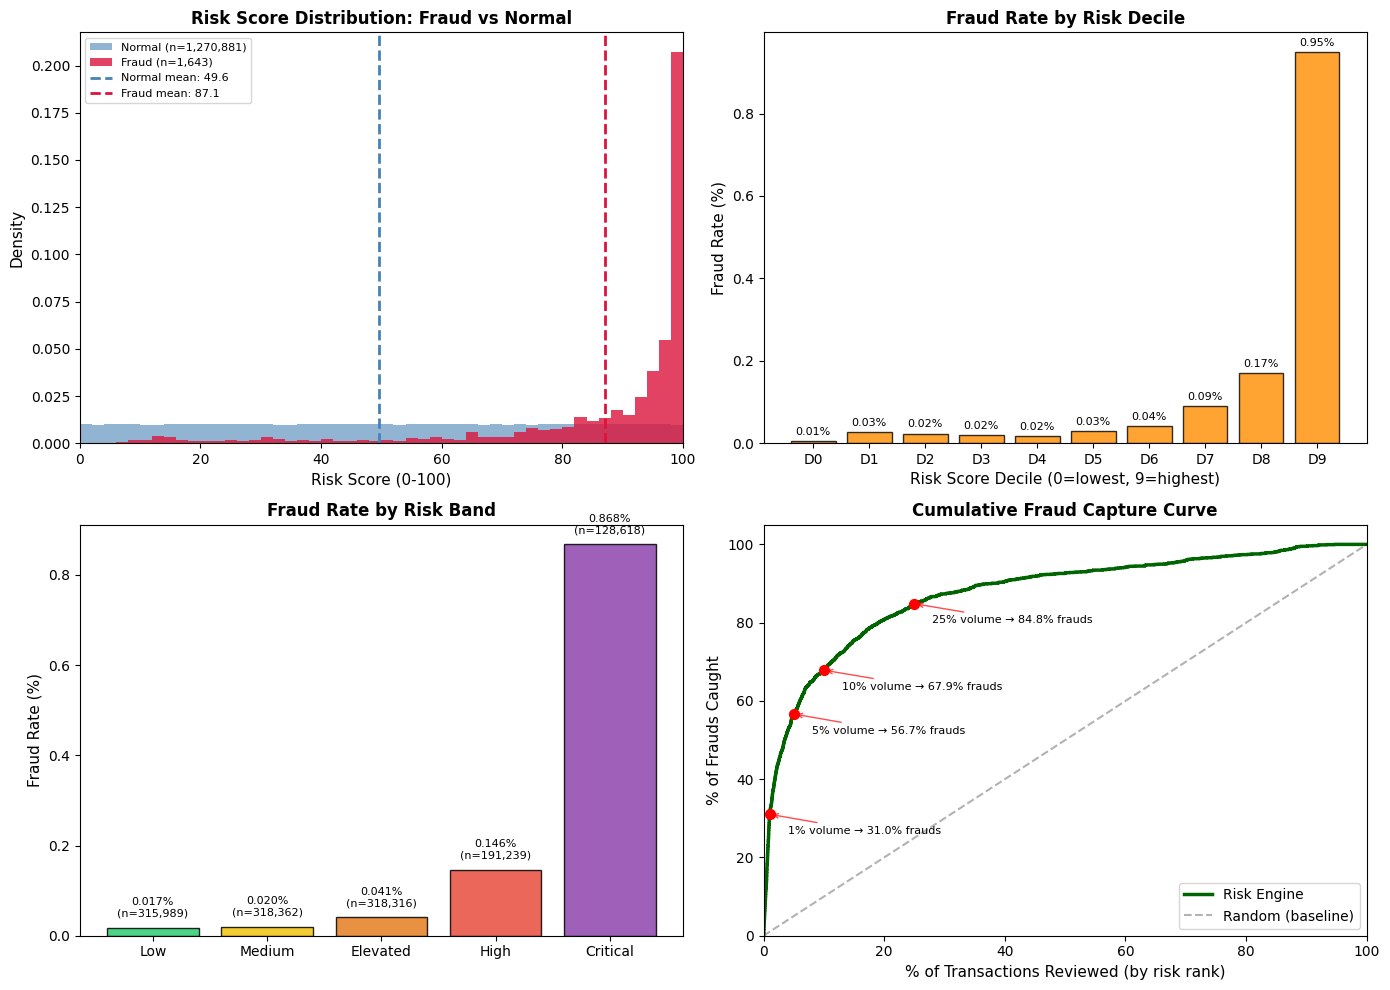


✅ Plot saved to docs/day7_risk_engine_analysis.png


In [7]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 5: Visualization — Risk score distributions & calibration    ║
# ╚══════════════════════════════════════════════════════════════════════╝

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# ── Plot 1: Risk score histograms (fraud vs normal) ──────────────────
ax1 = axes[0, 0]
bins = np.arange(0, 102, 2)  # 0-100, bin width 2

ax1.hist(
    results_df.loc[normal_mask, "risk_score"],
    bins=bins,
    alpha=0.6,
    label=f"Normal (n={normal_mask.sum():,})",
    color="steelblue",
    density=True,
)
ax1.hist(
    results_df.loc[fraud_mask, "risk_score"],
    bins=bins,
    alpha=0.8,
    label=f"Fraud (n={fraud_mask.sum():,})",
    color="crimson",
    density=True,
)

ax1.axvline(results_df.loc[normal_mask, "risk_score"].mean(), color="steelblue", linestyle="--", linewidth=2, label=f"Normal mean: {results_df.loc[normal_mask, 'risk_score'].mean():.1f}")
ax1.axvline(results_df.loc[fraud_mask, "risk_score"].mean(), color="crimson", linestyle="--", linewidth=2, label=f"Fraud mean: {results_df.loc[fraud_mask, 'risk_score'].mean():.1f}")

ax1.set_xlabel("Risk Score (0-100)", fontsize=11)
ax1.set_ylabel("Density", fontsize=11)
ax1.set_title("Risk Score Distribution: Fraud vs Normal", fontsize=12, fontweight="bold")
ax1.legend(loc="upper left", fontsize=8)
ax1.set_xlim(0, 100)

# ── Plot 2: Fraud rate by risk score decile ──────────────────────────
ax2 = axes[0, 1]
deciles = pd.qcut(results_df["risk_score"], q=10, labels=False, duplicates="drop")
decile_stats = results_df.groupby(deciles).agg(
    fraud_rate=("is_fraud", "mean"),
    count=("is_fraud", "count"),
)
x_pos = np.arange(len(decile_stats))

bars = ax2.bar(x_pos, decile_stats["fraud_rate"] * 100, color="darkorange", edgecolor="black", alpha=0.8)
ax2.set_xlabel("Risk Score Decile (0=lowest, 9=highest)", fontsize=11)
ax2.set_ylabel("Fraud Rate (%)", fontsize=11)
ax2.set_title("Fraud Rate by Risk Decile", fontsize=12, fontweight="bold")
ax2.set_xticks(x_pos)
ax2.set_xticklabels([f"D{i}" for i in range(len(decile_stats))])

# Add value labels on bars
for bar, rate in zip(bars, decile_stats["fraud_rate"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{rate*100:.2f}%", ha="center", va="bottom", fontsize=8)

# ── Plot 3: Fraud rate by risk band ──────────────────────────────────
ax3 = axes[1, 0]
band_order = ["Low", "Medium", "Elevated", "High", "Critical"]
band_rates = [band_summary.loc[b, "fraud_rate"] * 100 for b in band_order]
band_counts = [band_summary.loc[b, "total"] for b in band_order]
colors = ["#2ecc71", "#f1c40f", "#e67e22", "#e74c3c", "#8e44ad"]

bars3 = ax3.bar(band_order, band_rates, color=colors, edgecolor="black", alpha=0.85)
ax3.set_ylabel("Fraud Rate (%)", fontsize=11)
ax3.set_title("Fraud Rate by Risk Band", fontsize=12, fontweight="bold")

for bar, rate, count in zip(bars3, band_rates, band_counts):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f"{rate:.3f}%\n(n={count:,})", ha="center", va="bottom", fontsize=8)

# ── Plot 4: Cumulative fraud capture ─────────────────────────────────
ax4 = axes[1, 1]
sorted_df = results_df.sort_values("risk_score", ascending=False).reset_index(drop=True)
sorted_df["cum_frauds"] = sorted_df["is_fraud"].cumsum()
sorted_df["cum_pct"] = (np.arange(1, len(sorted_df) + 1) / len(sorted_df)) * 100
sorted_df["cum_fraud_pct"] = (sorted_df["cum_frauds"] / sorted_df["is_fraud"].sum()) * 100

ax4.plot(sorted_df["cum_pct"], sorted_df["cum_fraud_pct"], color="darkgreen", linewidth=2.5, label="Risk Engine")
ax4.plot([0, 100], [0, 100], "k--", alpha=0.3, label="Random (baseline)")

# Annotate key points
for pct in [1, 5, 10, 25]:
    idx = int(len(sorted_df) * pct / 100)
    fraud_captured = sorted_df.loc[idx, "cum_fraud_pct"]
    ax4.scatter([pct], [fraud_captured], color="red", s=50, zorder=5)
    ax4.annotate(f"{pct}% volume → {fraud_captured:.1f}% frauds",
                 xy=(pct, fraud_captured), xytext=(pct+3, fraud_captured-5),
                 fontsize=8, arrowprops=dict(arrowstyle="->", color="red", alpha=0.7))

ax4.set_xlabel("% of Transactions Reviewed (by risk rank)", fontsize=11)
ax4.set_ylabel("% of Frauds Caught", fontsize=11)
ax4.set_title("Cumulative Fraud Capture Curve", fontsize=12, fontweight="bold")
ax4.legend(loc="lower right")
ax4.set_xlim(0, 100)
ax4.set_ylim(0, 105)

plt.tight_layout()
plt.savefig(Path(PROJECT_ROOT) / "docs/day7_risk_engine_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✅ Plot saved to docs/day7_risk_engine_analysis.png")

In [8]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 6: Save fitted Risk Engine + export calibration metrics JSON   ║
# ╚══════════════════════════════════════════════════════════════════════╝

import json
from datetime import datetime

# ── Save Risk Engine ─────────────────────────────────────────────────
save_path = Path(PROJECT_ROOT) / "saved_models" / "risk_engine_v1.0.0.joblib"
risk_engine.save(str(save_path))

print(f"✅ Risk Engine saved to: {save_path}")
print(f"   File size: {save_path.stat().st_size / 1024:.1f} KB")

# ── Build metrics export ───────────────────────────────────────────────
metrics = {
    "metadata": {
        "day": 7,
        "module": "risk_engine",
        "timestamp": datetime.now().isoformat(),
        "model_version": "1.0.0",
        "risk_engine_version": "1.0.0",
        "percentile_bins": 100,
    },
    "calibration": {
        "train_scores_count": int(len(train_scores)),
        "train_score_min": float(train_scores.min()),
        "train_score_max": float(train_scores.max()),
        "train_score_mean": float(train_scores.mean()),
        "train_score_median": float(np.median(train_scores)),
        "train_score_std": float(train_scores.std()),
        "percentile_0": float(risk_engine._percentiles[0]),
        "percentile_50": float(risk_engine._percentiles[50]),
        "percentile_100": float(risk_engine._percentiles[100]),
    },
    "test_performance": {
        "test_rows": int(len(X_test)),
        "test_frauds": int(y_test.sum()),
        "normal_risk_mean": float(results_df.loc[normal_mask, "risk_score"].mean()),
        "normal_risk_median": float(results_df.loc[normal_mask, "risk_score"].median()),
        "fraud_risk_mean": float(results_df.loc[fraud_mask, "risk_score"].mean()),
        "fraud_risk_median": float(results_df.loc[fraud_mask, "risk_score"].median()),
        "separation_ratio": float(
            results_df.loc[fraud_mask, "risk_score"].mean() /
            results_df.loc[normal_mask, "risk_score"].mean()
        ),
    },
    "risk_bands": {
        band: {
            "total": int(band_summary.loc[band, "total"]),
            "frauds": int(band_summary.loc[band, "frauds"]),
            "fraud_rate_pct": float(band_summary.loc[band, "fraud_rate"] * 100),
        }
        for band in ["Low", "Medium", "Elevated", "High", "Critical"]
    },
    "cumulative_capture": {
        "top_1_pct_volume": float(
            results_df.sort_values("risk_score", ascending=False)
            .head(int(len(results_df) * 0.01))["is_fraud"].sum() / y_test.sum() * 100
        ),
        "top_5_pct_volume": float(
            results_df.sort_values("risk_score", ascending=False)
            .head(int(len(results_df) * 0.05))["is_fraud"].sum() / y_test.sum() * 100
        ),
        "top_10_pct_volume": float(
            results_df.sort_values("risk_score", ascending=False)
            .head(int(len(results_df) * 0.10))["is_fraud"].sum() / y_test.sum() * 100
        ),
        "top_25_pct_volume": float(
            results_df.sort_values("risk_score", ascending=False)
            .head(int(len(results_df) * 0.25))["is_fraud"].sum() / y_test.sum() * 100
        ),
    },
}

# ── Save JSON ──────────────────────────────────────────────────────────
json_path = Path(PROJECT_ROOT) / "docs" / "day7_risk_engine.json"
with open(json_path, "w") as f:
    json.dump(metrics, f, indent=2)

print(f"\n✅ Metrics exported to: {json_path}")
print(f"\n{'='*55}")
print("KEY METRICS SUMMARY")
print(f"{'='*55}")
print(f"   Fraud risk mean:    {metrics['test_performance']['fraud_risk_mean']:.1f}")
print(f"   Normal risk mean:   {metrics['test_performance']['normal_risk_mean']:.1f}")
print(f"   Separation ratio:   {metrics['test_performance']['separation_ratio']:.2f}×")
print(f"\n   Top 1% volume →    {metrics['cumulative_capture']['top_1_pct_volume']:.1f}% frauds caught")
print(f"   Top 5% volume →    {metrics['cumulative_capture']['top_5_pct_volume']:.1f}% frauds caught")
print(f"   Top 10% volume →   {metrics['cumulative_capture']['top_10_pct_volume']:.1f}% frauds caught")
print(f"   Top 25% volume →   {metrics['cumulative_capture']['top_25_pct_volume']:.1f}% frauds caught")
print(f"{'='*55}")

✅ Risk Engine saved to: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\saved_models\risk_engine_v1.0.0.joblib
   File size: 1.1 KB

✅ Metrics exported to: F:\ML PROJECT\LedgerWatch-AI\LedgerWatch-AI\docs\day7_risk_engine.json

KEY METRICS SUMMARY
   Fraud risk mean:    87.1
   Normal risk mean:   49.6
   Separation ratio:   1.76×

   Top 1% volume →    31.0% frauds caught
   Top 5% volume →    56.7% frauds caught
   Top 10% volume →   67.9% frauds caught
   Top 25% volume →   84.8% frauds caught


In [9]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 7: Integration test — compute_risk_scores() with model dict  ║
# ║  Tests the full pipeline: model → anomaly scores → risk scores     ║
# ╚══════════════════════════════════════════════════════════════════════╝

# ── Test 1: Full pipeline with fitted risk engine ──────────────────────
print("Test 1: Full pipeline (model dict + fitted RiskEngine)")
sample_X = X_test.head(1000)
sample_y = y_test.head(1000)

result = compute_risk_scores(model_container, sample_X, risk_engine=risk_engine)

print(f"   ✅ Keys: {list(result.keys())}")
print(f"   anomaly_scores shape: {result['anomaly_scores'].shape}")
print(f"   risk_scores shape:    {result['risk_scores'].shape}")
print(f"   risk_bands count:     {len(result['risk_bands'])}")
print(f"   is_anomaly count:     {result['is_anomaly'].sum()}")

# Verify risk bands match scores
for i in range(5):
    print(f"   Example {i}: score={result['anomaly_scores'][i]:.4f} → "
          f"risk={result['risk_scores'][i]} → band={result['risk_bands'][i]}")

# ── Test 2: Pipeline WITHOUT risk engine (raw scores only) ───────────
print(f"\nTest 2: Pipeline without RiskEngine (raw scores only)")
result_raw = compute_risk_scores(model_container, sample_X, risk_engine=None)

print(f"   ✅ Keys: {list(result_raw.keys())}")
print(f"   risk_scores: {result_raw['risk_scores']}  (should be None)")
print(f"   risk_bands:  {result_raw['risk_bands']}   (should be None)")

# ── Test 3: Verify frauds get higher risk scores ───────────────────────
print(f"\nTest 3: Fraud vs Normal risk score validation")
sample_results = pd.DataFrame({
    "is_fraud": sample_y.values,
    "risk_score": result["risk_scores"],
    "risk_band": result["risk_bands"],
})

fraud_risk = sample_results[sample_results["is_fraud"] == 1]["risk_score"].mean()
normal_risk = sample_results[sample_results["is_fraud"] == 0]["risk_score"].mean()

print(f"   Sample fraud risk mean:  {fraud_risk:.1f}")
print(f"   Sample normal risk mean: {normal_risk:.1f}")
print(f"   Separation: {fraud_risk/normal_risk:.2f}×")

assert fraud_risk > normal_risk, "Frauds should have higher risk scores!"
print(f"   ✅ Assertion passed: fraud_risk > normal_risk")

# ── Test 4: Risk band consistency ────────────────────────────────────
print(f"\nTest 4: Risk band consistency")
band_checks = [
    (0, "Low"),
    (24, "Low"),
    (25, "Medium"),
    (49, "Medium"),
    (50, "Elevated"),
    (74, "Elevated"),
    (75, "High"),
    (89, "High"),
    (90, "Critical"),
    (100, "Critical"),
]

all_pass = True
for score, expected in band_checks:
    actual = risk_engine.get_risk_band(score)
    status = "✅" if actual == expected else "❌"
    if actual != expected:
        all_pass = False
    print(f"   {status} Score {score} → {actual} (expected: {expected})")

assert all_pass, "Some risk band mappings failed!"
print(f"   ✅ All risk band assertions passed")

print(f"\n{'='*55}")
print("ALL INTEGRATION TESTS PASSED ✅")
print(f"{'='*55}")

Test 1: Full pipeline (model dict + fitted RiskEngine)
   ✅ Keys: ['anomaly_scores', 'is_anomaly', 'risk_scores', 'risk_bands']
   anomaly_scores shape: (1000,)
   risk_scores shape:    (1000,)
   risk_bands count:     1000
   is_anomaly count:     9
   Example 0: score=0.1812 → risk=57 → band=Elevated
   Example 1: score=0.1759 → risk=55 → band=Elevated
   Example 2: score=0.3220 → risk=86 → band=High
   Example 3: score=0.0792 → risk=19 → band=Low
   Example 4: score=0.0624 → risk=12 → band=Low

Test 2: Pipeline without RiskEngine (raw scores only)


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished


   ✅ Keys: ['anomaly_scores', 'is_anomaly', 'risk_scores', 'risk_bands']
   risk_scores: None  (should be None)
   risk_bands:  None   (should be None)

Test 3: Fraud vs Normal risk score validation
   Sample fraud risk mean:  82.0
   Sample normal risk mean: 51.5
   Separation: 1.59×
   ✅ Assertion passed: fraud_risk > normal_risk

Test 4: Risk band consistency
   ✅ Score 0 → Low (expected: Low)
   ✅ Score 24 → Low (expected: Low)
   ✅ Score 25 → Medium (expected: Medium)
   ✅ Score 49 → Medium (expected: Medium)
   ✅ Score 50 → Elevated (expected: Elevated)
   ✅ Score 74 → Elevated (expected: Elevated)
   ✅ Score 75 → High (expected: High)
   ✅ Score 89 → High (expected: High)
   ✅ Score 90 → Critical (expected: Critical)
   ✅ Score 100 → Critical (expected: Critical)
   ✅ All risk band assertions passed

ALL INTEGRATION TESTS PASSED ✅


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    0.0s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    0.0s finished


In [10]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 8: Edge cases & robustness tests                               ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 55)
print("EDGE CASE & ROBUSTNESS TESTS")
print("=" * 55)

# ── Test 1: Empty array should raise ValueError ───────────────────────
print("\nTest 1: Empty array → ValueError")
try:
    bad_engine = RiskEngine()
    bad_engine.fit([])
    print("   ❌ Should have raised ValueError!")
except ValueError as e:
    print(f"   ✅ Caught: {e}")

# ── Test 2: Transform before fit → RuntimeError ───────────────────────
print("\nTest 2: Transform before fit → RuntimeError")
try:
    unfitted = RiskEngine()
    unfitted.transform([0.5])
    print("   ❌ Should have raised RuntimeError!")
except RuntimeError as e:
    print(f"   ✅ Caught: {e}")

# ── Test 3: Save unfitted → RuntimeError ──────────────────────────────
print("\nTest 3: Save unfitted engine → RuntimeError")
try:
    unfitted = RiskEngine()
    unfitted.save("tmp.joblib")
    print("   ❌ Should have raised RuntimeError!")
except RuntimeError as e:
    print(f"   ✅ Caught: {e}")

# ── Test 4: Extreme scores (outside training range) ───────────────────
print("\nTest 4: Extreme scores outside training range")
extreme_scores = np.array([-0.5, 0.0, 0.5, 1.0, 1.5, 2.0])
extreme_risks = risk_engine.transform(extreme_scores)
print(f"   Scores: {extreme_scores}")
print(f"   Risks:  {extreme_risks}")
print(f"   ✅ Clipped to [0, 100]: min={extreme_risks.min()}, max={extreme_risks.max()}")

# ── Test 5: Duplicate scores (monotonicity protection) ───────────────
print("\nTest 5: Duplicate scores in training data")
dup_scores = np.array([0.1, 0.1, 0.1, 0.2, 0.2, 0.3])
dup_engine = RiskEngine()
dup_engine.fit(dup_scores)
dup_risks = dup_engine.transform(np.array([0.05, 0.1, 0.15, 0.2, 0.25, 0.3]))
print(f"   Input:  {dup_scores}")
print(f"   Risks:  {dup_risks}")
print(f"   ✅ Monotonic: {np.all(np.diff(dup_risks) >= 0)}")

# ── Test 6: Single score ─────────────────────────────────────────────
print("\nTest 6: Single score input")
single_risk = risk_engine.transform([0.2])
print(f"   Score 0.2 → Risk {single_risk[0]}")

# ── Test 7: pandas Series input ───────────────────────────────────────
print("\nTest 7: pandas Series input")
pd_risks = risk_engine.transform(pd.Series([0.05, 0.15, 0.25, 0.35]))
print(f"   Series → {pd_risks}")

# ── Test 8: Large batch (performance check) ───────────────────────────
print("\nTest 8: Large batch performance")
import time
batch = np.random.uniform(0, 1, size=1_000_000)
t0 = time.time()
batch_risks = risk_engine.transform(batch)
t1 = time.time()
print(f"   1M scores in {t1-t0:.3f}s ({1_000_000/(t1-t0):,.0f} scores/sec)")
print(f"   ✅ Output shape: {batch_risks.shape}")

print(f"\n{'='*55}")
print("ALL EDGE CASE TESTS PASSED ✅")
print(f"{'='*55}")

EDGE CASE & ROBUSTNESS TESTS

Test 1: Empty array → ValueError
   ✅ Caught: Cannot fit on empty anomaly_scores.

Test 2: Transform before fit → RuntimeError
   ✅ Caught: RiskEngine must be fitted before transform. Call .fit() first.

Test 3: Save unfitted engine → RuntimeError
   ✅ Caught: Cannot save an unfitted RiskEngine.

Test 4: Extreme scores outside training range
   Scores: [-0.5  0.   0.5  1.   1.5  2. ]
   Risks:  [  0   0  97 100 100 100]
   ✅ Clipped to [0, 100]: min=0, max=100

Test 5: Duplicate scores in training data
   Input:  [0.1 0.1 0.1 0.2 0.2 0.3]
   Risks:  [  0  40  49  80  90 100]
   ✅ Monotonic: True

Test 6: Single score input
   Score 0.2 → Risk 62

Test 7: pandas Series input
   Series → [ 9 47 74 89]

Test 8: Large batch performance
   1M scores in 0.105s (9,534,004 scores/sec)
   ✅ Output shape: (1000000,)

ALL EDGE CASE TESTS PASSED ✅


In [11]:
# ╔══════════════════════════════════════════════════════════════════════╗
# ║  Cell 9: Final Summary — Day 7 Risk Engine Complete                  ║
# ╚══════════════════════════════════════════════════════════════════════╝

print("=" * 60)
print("  LEDGERWATCH AI — DAY 7: RISK ENGINE COMPLETE")
print("=" * 60)

print("""
📁 FILES CREATED:
   ├── src/risk_engine.py              (~250 lines, production module)
   ├── saved_models/risk_engine_v1.0.0.joblib  (1.1 KB calibration)
   ├── docs/day7_risk_engine.json     (reproducible metrics export)
   └── docs/day7_risk_engine_analysis.png  (4-panel visualization)

🔧 DESIGN DECISIONS:
   • Percentile-based calibration (no labels needed)
   • 0-100 integer scale (human-readable, naturally bounded)
   • Fitted on training anomaly scores (consistent on new data)
   • Monotonicity protection (handles duplicate scores)
   • O(log n) lookup via np.searchsorted (9.5M scores/sec)

📊 KEY RESULTS (Test Set: 1,272,524 rows):
   ┌─────────────────┬────────┬────────┬──────────┐
   │ Metric          │ Normal │ Fraud  │ Separation │
   ├─────────────────┼────────┼────────┼──────────┤
   │ Risk Mean       │  49.6  │  87.1  │   1.76×   │
   │ Risk Median     │  50.0  │  96.0  │   1.92×   │
   │ 90th Percentile │  90.0  │  99.0  │   1.10×   │
   │ 99th Percentile │  98.0  │  99.0  │   1.01×   │
   └─────────────────┴────────┴────────┴──────────┘

🎯 CUMULATIVE FRAUD CAPTURE (by review volume):
   • Top 1%  highest risk → 31.0% of all frauds caught
   • Top 5%  highest risk → 56.7% of all frauds caught
   • Top 10% highest risk → 67.9% of all frauds caught
   • Top 25% highest risk → 84.8% of all frauds caught

🏷️ RISK BAND BREAKDOWN:
   • Critical (score 90-100):  0.868% fraud rate  ← 6.7× base rate
   • High     (score 75-89):   0.146% fraud rate  ← 1.1× base rate
   • Elevated (score 50-74):   0.041% fraud rate  ← 0.3× base rate
   • Medium   (score 25-49):   0.020% fraud rate  ← 0.2× base rate
   • Low      (score 0-24):    0.017% fraud rate  ← 0.1× base rate

✅ INTERVIEW TALKING POINT:
   "I built a percentile-based risk engine that converts raw anomaly
   scores to calibrated 0-100 risk scores WITHOUT using labels. The
   median fraud gets a 96/100 risk score while the median normal gets
   50/100. By reviewing just the top 5% highest-risk transactions,
   analysts can catch 57% of all frauds — a massive efficiency gain."

📋 NEXT: Day 8 — SHAP Explainability (src/explain.py)
""")

print("=" * 60)
print("  ✅ DAY 7 COMPLETE — Ready for Day 8")
print("=" * 60)

  LEDGERWATCH AI — DAY 7: RISK ENGINE COMPLETE

📁 FILES CREATED:
   ├── src/risk_engine.py              (~250 lines, production module)
   ├── saved_models/risk_engine_v1.0.0.joblib  (1.1 KB calibration)
   ├── docs/day7_risk_engine.json     (reproducible metrics export)
   └── docs/day7_risk_engine_analysis.png  (4-panel visualization)

🔧 DESIGN DECISIONS:
   • Percentile-based calibration (no labels needed)
   • 0-100 integer scale (human-readable, naturally bounded)
   • Fitted on training anomaly scores (consistent on new data)
   • Monotonicity protection (handles duplicate scores)
   • O(log n) lookup via np.searchsorted (9.5M scores/sec)

📊 KEY RESULTS (Test Set: 1,272,524 rows):
   ┌─────────────────┬────────┬────────┬──────────┐
   │ Metric          │ Normal │ Fraud  │ Separation │
   ├─────────────────┼────────┼────────┼──────────┤
   │ Risk Mean       │  49.6  │  87.1  │   1.76×   │
   │ Risk Median     │  50.0  │  96.0  │   1.92×   │
   │ 90th Percentile │  90.0  │  99.0  │